# ใบงานที่ 5: Support Vector Machine (SVM) และการประยุกต์ใช้งาน SVM

## LEB: SVM on a Dataset of Your Choice

**Dataset ที่เลือก:** [Fake Bills](https://www.kaggle.com/datasets/alexandrepetit881234/fake-bills) — ชุดข้อมูลค่าการวัดทางเรขาคณิตของธนบัตร (ฝรั่งเศส) จำนวน 1,500 ใบ ประกอบด้วยธนบัตรจริง 1,000 ใบ และธนบัตรปลอม 500 ใบ ใช้สำหรับจำแนก (classification) ว่าธนบัตรใบใดเป็นของจริง (`is_genuine = True`) หรือของปลอม (`is_genuine = False`)

**คอลัมน์ในชุดข้อมูล**

| คอลัมน์ | ความหมาย |
|---|---|
| `is_genuine` | เป้าหมาย (target): True = ธนบัตรจริง, False = ธนบัตรปลอม |
| `diagonal` | ความยาวเส้นทแยงมุมของธนบัตร (มม.) |
| `height_left` | ความสูงด้านซ้ายของธนบัตร (มม.) |
| `height_right` | ความสูงด้านขวาของธนบัตร (มม.) |
| `margin_low` | ระยะขอบด้านล่าง (มม.) |
| `margin_up` | ระยะขอบด้านบน (มม.) |
| `length` | ความยาวของธนบัตร (มม.) |

**สิ่งที่ทำในใบงานนี้**
1. โหลดและสำรวจข้อมูล (EDA)
2. เตรียมข้อมูล (จัดการค่าที่หายไป, เข้ารหัสตัวแปรเป้าหมาย)
3. ปรับมาตรฐานฟีเจอร์ (Standardization) ก่อนนำเข้าโมเดล
4. ฝึกโมเดล SVM 3 แบบ kernel: **Linear, Polynomial, RBF**
5. ประเมินผลด้วยค่า Accuracy พร้อม Confusion Matrix และ Classification Report
6. เปรียบเทียบประสิทธิภาพของแต่ละ kernel
7. ทดลองทำนายผลกับข้อมูลตัวอย่างใหม่ (unseen samples)


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
)
from sklearn.decomposition import PCA

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2. Load Dataset

ให้ดาวน์โหลดไฟล์ `fake_bills.csv` จาก Kaggle ([alexandrepetit881234/fake-bills](https://www.kaggle.com/datasets/alexandrepetit881234/fake-bills)) แล้ววางไว้ในโฟลเดอร์เดียวกับโน้ตบุ๊กนี้

ไฟล์ต้นฉบับจาก Kaggle คั่นด้วยเครื่องหมาย semicolon (`;`) โค้ดด้านล่างจะพยายามอ่านไฟล์จริงก่อน ถ้าไม่พบไฟล์ จะสร้างชุดข้อมูลตัวอย่าง (synthetic) ที่มีโครงสร้างและคุณสมบัติทางสถิติใกล้เคียงกับชุดข้อมูลจริงขึ้นมาแทน **เพื่อให้โน้ตบุ๊กรันได้ครบทุกขั้นตอนไว้ทดสอบก่อน** — เมื่อมีไฟล์จริงแล้วให้รันใหม่อีกครั้ง โค้ดจะสลับไปใช้ไฟล์จริงโดยอัตโนมัติ

In [2]:
import os

DATA_PATH = "fake_bills.csv"

def load_real_dataset(path):
    df_ = pd.read_csv(path, sep=";")
    return df_

def make_synthetic_fallback(n_genuine=1000, n_fake=500, seed=RANDOM_STATE):
    '''Placeholder generator, used ONLY if fake_bills.csv is not found locally.
    Mimics the schema and rough scale of the real Fake Bills dataset (6 numeric
    features + boolean target) so the pipeline below can be built and tested
    end-to-end before the real file is downloaded.'''
    rng = np.random.default_rng(seed)

    genuine = pd.DataFrame({
        "diagonal":     rng.normal(171.96, 0.31, n_genuine),
        "height_left":  rng.normal(104.02, 0.30, n_genuine),
        "height_right": rng.normal(103.97, 0.32, n_genuine),
        "margin_low":   rng.normal(4.10, 0.40, n_genuine),
        "margin_up":    rng.normal(3.03, 0.23, n_genuine),
        "length":       rng.normal(113.29, 0.71, n_genuine),
    })
    genuine["is_genuine"] = True

    fake = pd.DataFrame({
        "diagonal":     rng.normal(171.95, 0.31, n_fake),
        "height_left":  rng.normal(104.26, 0.31, n_fake),
        "height_right": rng.normal(104.42, 0.33, n_fake),
        "margin_low":   rng.normal(5.20, 0.48, n_fake),
        "margin_up":    rng.normal(3.36, 0.23, n_fake),
        "length":       rng.normal(112.10, 0.65, n_fake),
    })
    fake["is_genuine"] = False

    df_ = pd.concat([genuine, fake], ignore_index=True)
    # sprinkle a few missing values in margin_low, like the real dataset has
    missing_idx = rng.choice(df_.index, size=int(0.02 * len(df_)), replace=False)
    df_.loc[missing_idx, "margin_low"] = np.nan
    return df_.sample(frac=1, random_state=seed).reset_index(drop=True)


if os.path.exists(DATA_PATH):
    df = load_real_dataset(DATA_PATH)
    print(f"Loaded real dataset from '{DATA_PATH}' -> shape {df.shape}")
else:
    df = make_synthetic_fallback()
    print(
        f"'{DATA_PATH}' not found — using a SYNTHETIC placeholder dataset "
        f"(shape {df.shape}) so the notebook can run end-to-end.\n"
        "Download the real file from Kaggle and place it next to this notebook, "
        "then re-run this cell to use the real data."
    )

df.head()


'fake_bills.csv' not found — using a SYNTHETIC placeholder dataset (shape (1500, 7)) so the notebook can run end-to-end.
Download the real file from Kaggle and place it next to this notebook, then re-run this cell to use the real data.


,diagonal,height_left,height_right,margin_low,margin_up,length,is_genuine
0,171.542775,104.285274,104.484154,5.836852,3.484673,112.013624,False
1,171.657943,103.812835,104.865275,5.619408,3.427464,111.761414,False
2,171.775736,104.137159,104.465965,4.525725,2.703003,113.163370,True
3,172.192325,104.398281,103.508768,3.956775,2.857033,113.948331,True
4,172.068121,104.172969,103.840988,4.381676,2.973216,112.672054,True


## 3. Exploratory Data Analysis (EDA)

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   diagonal      1500 non-null   float64
 1   height_left   1500 non-null   float64
 2   height_right  1500 non-null   float64
 3   margin_low    1470 non-null   float64
 4   margin_up     1500 non-null   float64
 5   length        1500 non-null   float64
 6   is_genuine    1500 non-null   bool   
dtypes: bool(1), float64(6)
memory usage: 71.9 KB


In [4]:
df.describe()


,diagonal,height_left,height_right,margin_low,margin_up,length
count,1500.000000,1500.000000,1500.000000,1470.000000,1500.000000,1500.000000
mean,171.955600,104.081819,104.125504,4.450968,3.142054,112.909125
std,0.311321,0.331231,0.381795,0.657669,0.280839,0.921327
min,170.828992,103.105710,102.989590,3.000226,2.306957,109.806014
25%,171.745146,103.860639,103.857453,3.968392,2.945011,112.245012
50%,171.954191,104.084411,104.120631,4.328061,3.122585,112.976465
75%,172.159479,104.283782,104.381729,4.917003,3.336758,113.568347
max,172.945445,105.128027,105.506972,6.696018,4.285940,115.591294


In [5]:
print("Missing values per column:")
print(df.isna().sum())


Missing values per column:
diagonal         0
height_left      0
height_right     0
margin_low      30
margin_up        0
length           0
is_genuine       0
dtype: int64


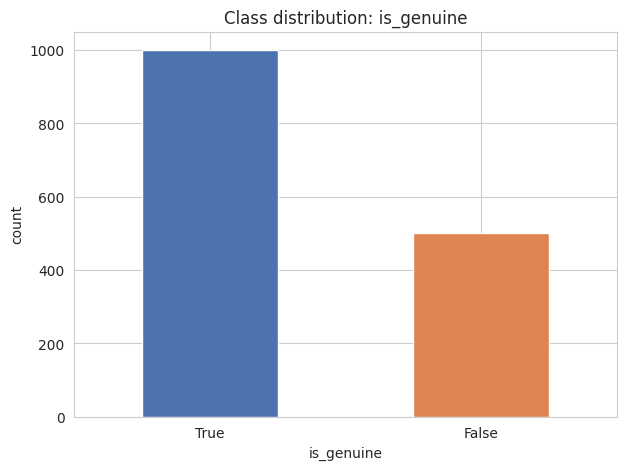

is_genuine
True     1000
False     500
Name: count, dtype: int64

In [6]:
ax = df["is_genuine"].value_counts().plot(kind="bar", color=["#4C72B0", "#DD8452"])
ax.set_title("Class distribution: is_genuine")
ax.set_xlabel("is_genuine")
ax.set_ylabel("count")
plt.xticks(rotation=0)
plt.show()

df["is_genuine"].value_counts()


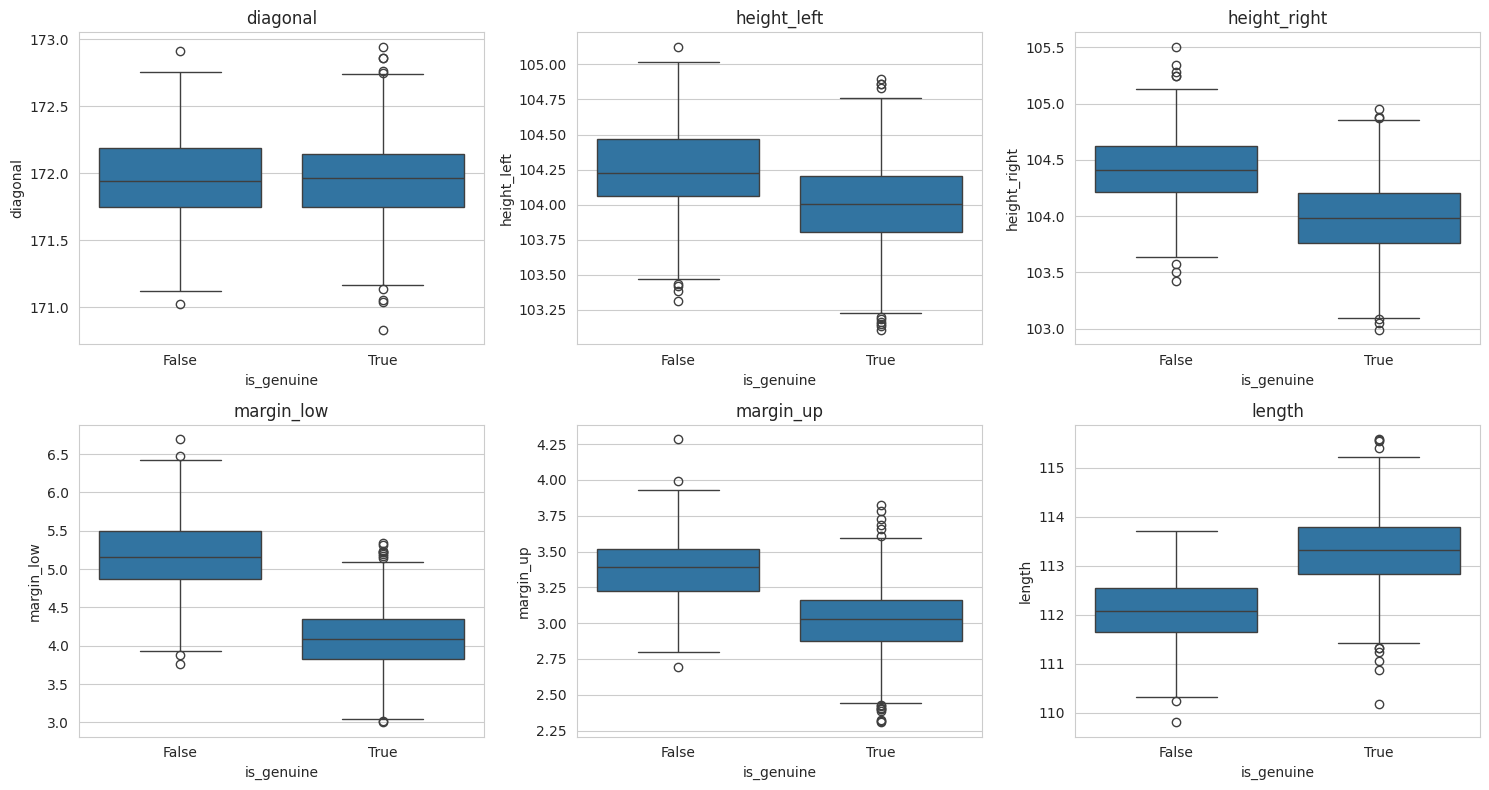

In [7]:
feature_cols = ["diagonal", "height_left", "height_right", "margin_low", "margin_up", "length"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for col, ax in zip(feature_cols, axes.ravel()):
    sns.boxplot(data=df, x="is_genuine", y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


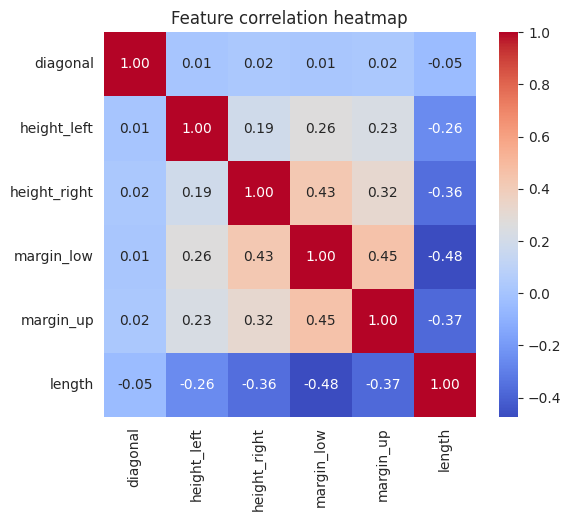

In [8]:
corr = df[feature_cols].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature correlation heatmap")
plt.show()


## 4. Data Preprocessing

- จัดการค่าที่หายไป (`margin_low` มีค่า missing บางส่วน) ด้วยการเติมค่าเฉลี่ย (mean imputation)
- แปลงตัวแปรเป้าหมาย `is_genuine` (True/False) เป็นตัวเลข 1/0
- แบ่งข้อมูลเป็น train / test
- ปรับมาตรฐานฟีเจอร์ด้วย `StandardScaler` (fit บน train set เท่านั้น เพื่อป้องกัน data leakage)

In [9]:
X = df[feature_cols].copy()
y = df["is_genuine"].astype(int)  # True/False -> 1/0

imputer = SimpleImputer(strategy="mean")
X = pd.DataFrame(imputer.fit_transform(X), columns=feature_cols)

print("Missing values after imputation:", X.isna().sum().sum())
X.head()


Missing values after imputation: 0


,diagonal,height_left,height_right,margin_low,margin_up,length
0,171.542775,104.285274,104.484154,5.836852,3.484673,112.013624
1,171.657943,103.812835,104.865275,5.619408,3.427464,111.761414
2,171.775736,104.137159,104.465965,4.525725,2.703003,113.163370
3,172.192325,104.398281,103.508768,3.956775,2.857033,113.948331
4,172.068121,104.172969,103.840988,4.381676,2.973216,112.672054


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (1200, 6)  Test shape: (300, 6)


In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_cols)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_cols)
X_train_scaled.describe().loc[["mean", "std"]]


,diagonal,height_left,height_right,margin_low,margin_up,length
mean,-8.096634e-14,-1.151671e-15,-2.226367e-15,8.556119e-16,1.628327e-17,-1.320869e-14
std,1.000417e+00,1.000417e+00,1.000417e+00,1.000417e+00,1.000417e+00,1.000417e+00


## 5. Train SVM Models (Linear, Polynomial, RBF kernels)

In [12]:
kernels = {
    "Linear":     SVC(kernel="linear", C=1.0, random_state=RANDOM_STATE),
    "Polynomial": SVC(kernel="poly", degree=3, C=1.0, gamma="scale", random_state=RANDOM_STATE),
    "RBF":        SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE),
}

trained_models = {}
results = {}

for name, model in kernels.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)

    trained_models[name] = model
    results[name] = {"y_pred": y_pred, "accuracy": acc}

    print(f"{name:>10} kernel -> accuracy = {acc:.4f}")


    Linear kernel -> accuracy = 0.9667
Polynomial kernel -> accuracy = 0.9533
       RBF kernel -> accuracy = 0.9667


## 6. Evaluation: Accuracy, Confusion Matrix, Classification Report

In [13]:
for name in kernels:
    y_pred = results[name]["y_pred"]
    print("=" * 55)
    print(f"Kernel: {name}   |   Accuracy: {results[name]['accuracy']:.4f}")
    print("-" * 55)
    print(classification_report(y_test, y_pred, target_names=["Fake (0)", "Genuine (1)"]))


Kernel: Linear   |   Accuracy: 0.9667
-------------------------------------------------------
              precision    recall  f1-score   support

    Fake (0)       0.94      0.96      0.95       100
 Genuine (1)       0.98      0.97      0.97       200

    accuracy                           0.97       300
   macro avg       0.96      0.96      0.96       300
weighted avg       0.97      0.97      0.97       300

Kernel: Polynomial   |   Accuracy: 0.9533
-------------------------------------------------------
              precision    recall  f1-score   support

    Fake (0)       0.97      0.89      0.93       100
 Genuine (1)       0.95      0.98      0.97       200

    accuracy                           0.95       300
   macro avg       0.96      0.94      0.95       300
weighted avg       0.95      0.95      0.95       300

Kernel: RBF   |   Accuracy: 0.9667
-------------------------------------------------------
              precision    recall  f1-score   support

    Fake

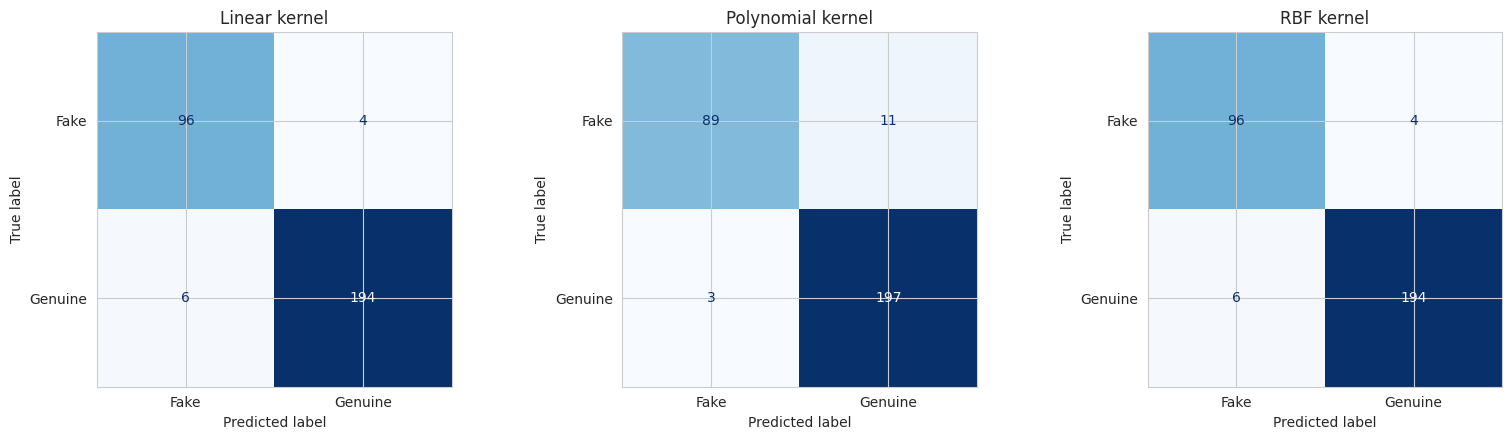

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, name in zip(axes, kernels):
    cm = confusion_matrix(y_test, results[name]["y_pred"])
    disp = ConfusionMatrixDisplay(cm, display_labels=["Fake", "Genuine"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{name} kernel")
plt.tight_layout()
plt.show()


## 7. Compare Kernel Accuracies

,kernel,accuracy
0,Linear,0.966667
1,RBF,0.966667
2,Polynomial,0.953333


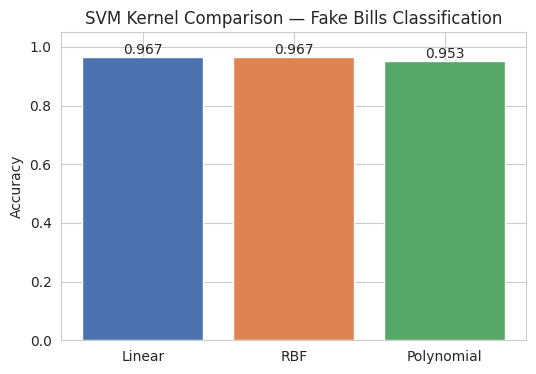

Best performing kernel: Linear (accuracy = 0.9667)


In [15]:
acc_df = pd.DataFrame({
    "kernel": list(results.keys()),
    "accuracy": [results[k]["accuracy"] for k in results],
}).sort_values("accuracy", ascending=False).reset_index(drop=True)

display(acc_df)

plt.figure(figsize=(6, 4))
bars = plt.bar(acc_df["kernel"], acc_df["accuracy"], color=["#4C72B0", "#DD8452", "#55A868"])
plt.ylim(0, 1.05)
plt.ylabel("Accuracy")
plt.title("SVM Kernel Comparison — Fake Bills Classification")
for b, a in zip(bars, acc_df["accuracy"]):
    plt.text(b.get_x() + b.get_width() / 2, a + 0.01, f"{a:.3f}", ha="center")
plt.show()

best_kernel = acc_df.iloc[0]["kernel"]
print(f"Best performing kernel: {best_kernel} (accuracy = {acc_df.iloc[0]['accuracy']:.4f})")


## 8. Decision Boundary Visualization (2D, via PCA)

เพื่อให้เห็นภาพว่าแต่ละ kernel แบ่งขอบเขตการตัดสินใจ (decision boundary) ต่างกันอย่างไร จะลดมิติของฟีเจอร์ทั้ง 6 ตัวลงเหลือ 2 มิติด้วย PCA แล้วฝึกโมเดลใหม่บนพื้นที่ 2 มิตินี้เพื่อพล็อตเท่านั้น (ใช้เพื่อการมองเห็นภาพ ไม่ใช่โมเดลที่นำไปใช้จริง)

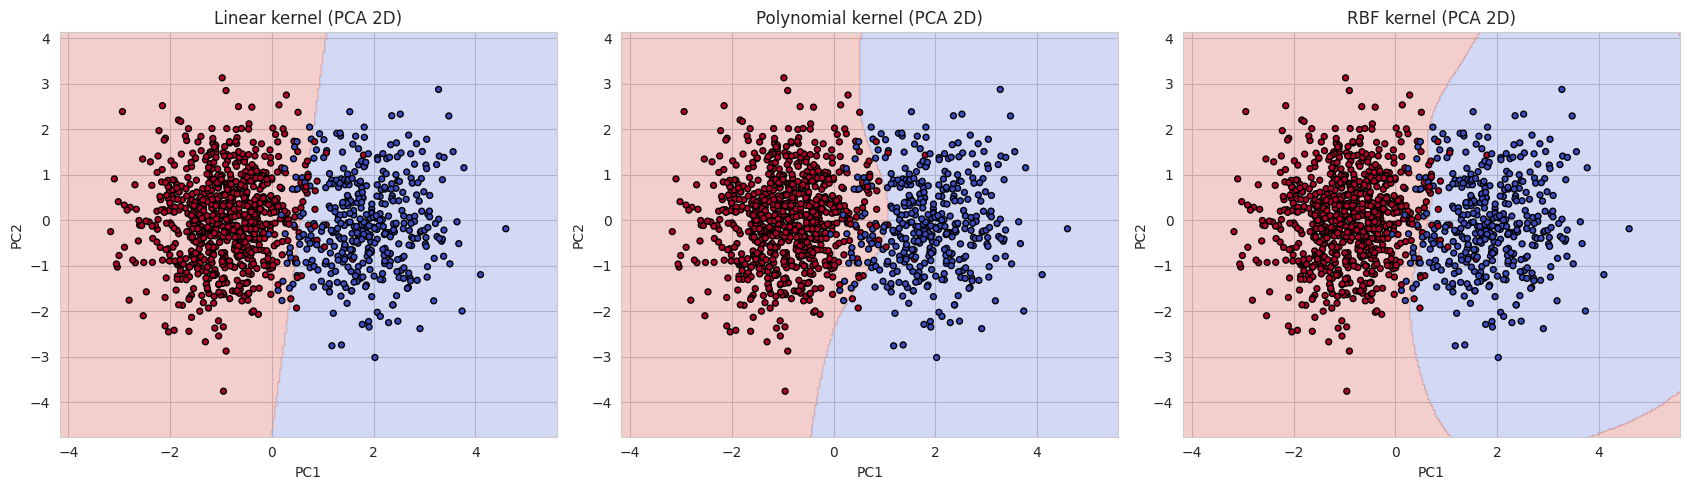

In [16]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_2d = pca.fit_transform(X_train_scaled)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

xx, yy = np.meshgrid(
    np.linspace(X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1, 300),
    np.linspace(X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1, 300),
)

for ax, (name, base_model) in zip(axes, kernels.items()):
    viz_model = SVC(**{k: v for k, v in base_model.get_params().items()
                        if k in ["kernel", "degree", "C", "gamma", "random_state"]})
    viz_model.fit(X_train_2d, y_train)

    Z = viz_model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
    ax.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, cmap="coolwarm",
               edgecolors="k", s=18)
    ax.set_title(f"{name} kernel (PCA 2D)")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.tight_layout()
plt.show()


## 9. Predictions on New / Unseen Bill Samples

ทดลองใช้โมเดลที่ดีที่สุด (best kernel) ทำนายผลกับ (ก) ตัวอย่างจาก test set บางส่วน และ (ข) ธนบัตรตัวอย่างใหม่ที่กำหนดค่าฟีเจอร์เองเพื่อจำลองสถานการณ์ใช้งานจริง

In [17]:
best_model = trained_models[best_kernel]

sample_test = X_test.sample(10, random_state=RANDOM_STATE)
sample_test_scaled = scaler.transform(sample_test)
sample_pred = best_model.predict(sample_test_scaled)

sample_out = sample_test.copy()
sample_out["actual"] = y_test.loc[sample_test.index].map({1: "Genuine", 0: "Fake"})
sample_out["predicted"] = pd.Series(sample_pred, index=sample_test.index).map({1: "Genuine", 0: "Fake"})
sample_out


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


,diagonal,height_left,height_right,margin_low,margin_up,length,actual,predicted
503,171.549963,104.493756,104.248663,4.631392,3.156579,114.053751,Genuine,Genuine
840,171.716165,104.474911,104.171996,3.774332,3.188828,112.429331,Genuine,Genuine
48,172.201108,103.609500,103.667785,3.904792,2.850337,113.611100,Genuine,Genuine
19,172.155699,103.958779,103.578094,3.726304,3.007181,113.395238,Genuine,Genuine
984,172.001972,103.632844,104.280029,5.453736,3.667368,112.053056,Fake,Fake
175,171.795874,104.485564,103.872409,3.639363,3.177381,113.158216,Genuine,Genuine
1171,171.969637,104.221634,104.047888,3.960652,2.624740,112.257214,Genuine,Genuine
737,172.290839,104.717734,103.849647,3.931465,3.127577,112.152385,Genuine,Genuine
605,171.601532,103.974092,104.279760,4.921818,3.214271,113.638162,Genuine,Genuine
399,172.065645,103.704434,103.796559,4.073982,3.307305,113.043324,Genuine,Genuine


In [18]:
# Custom "new" bills with hand-picked feature values, for demonstration
new_bills = pd.DataFrame({
    "diagonal":     [171.90, 171.80],
    "height_left":  [104.00, 104.35],
    "height_right": [103.95, 104.50],
    "margin_low":   [4.15,   5.30],
    "margin_up":    [3.05,   3.40],
    "length":       [113.20, 111.95],
})

new_bills_scaled = scaler.transform(new_bills)
new_preds = best_model.predict(new_bills_scaled)

new_bills_result = new_bills.copy()
new_bills_result["predicted"] = pd.Series(new_preds).map({1: "Genuine", 0: "Fake"})
print(f"Predictions using best kernel: {best_kernel}")
new_bills_result


Predictions using best kernel: Linear


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


,diagonal,height_left,height_right,margin_low,margin_up,length,predicted
0,171.9,104.00,103.95,4.15,3.05,113.20,Genuine
1,171.8,104.35,104.50,5.30,3.40,111.95,Fake


## 10. สรุปผล (Conclusion)

- ชุดข้อมูล **Fake Bills** ถูกนำมาใช้จำแนกธนบัตรจริง/ปลอมด้วยค่าการวัดทางเรขาคณิต 6 ค่า
- หลังจากเติมค่าที่หายไปและปรับมาตรฐานฟีเจอร์แล้ว ฝึกโมเดล SVM ทั้ง 3 kernel (Linear, Polynomial, RBF)
- ผลลัพธ์ accuracy ของแต่ละ kernel และ kernel ที่ให้ผลดีที่สุดในการรันครั้งนี้ แสดงไว้ในตารางเปรียบเทียบด้านบน (ส่วนที่ 7)
- ควรทดลองปรับค่า hyperparameter เช่น `C`, `gamma`, `degree` เพิ่มเติม (เช่นด้วย `GridSearchCV`) เพื่อดูว่าปรับปรุงผลลัพธ์ได้อีกหรือไม่

> **หมายเหตุ:** ถ้ายังไม่ได้วางไฟล์ `fake_bills.csv` จริงไว้ในโฟลเดอร์เดียวกับโน้ตบุ๊กนี้ ผลลัพธ์ทั้งหมดด้านบนจะมาจากชุดข้อมูลตัวอย่าง (synthetic placeholder) ที่สร้างขึ้นเพื่อทดสอบโค้ดเท่านั้น ให้ดาวน์โหลดไฟล์จริงจาก Kaggle แล้วรันโน้ตบุ๊กใหม่อีกครั้งก่อนส่งงาน
